# EDA Deep Dive — Urban Flood Modelling (Model 1 vs Model 2)

**Purpose:** Rigorous exploratory data analysis to identify feature transformations, outliers, and physical constraints.

**Checklist:**
1. Target distribution (Water_Level, Depth) — heavy-tailed? Log-transform needed?
2. Stationarity — autocorrelation of water levels
3. Outlier hunt — Model 1 depth std=24.8; isolate problem nodes
4. 1D-2D correlation — rainfall vs pipe surcharge lag
5. Dry node imbalance — % of nodes with depth=0

In [1]:
# ── Cell 1: Imports & Data Load ─────────────────────────────────────
import sys
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'experiments' else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))
os.environ.setdefault("FLOOD_DATA_PATH", str(PROJECT_ROOT / "data"))

from src.config import RAW_DATA_PATH
from src.dataset import FloodDataset
from src.utils_2d import wse_to_depth, get_min_elevation_filled

ds = FloodDataset(str(RAW_DATA_PATH), mode="train")
print(f"Loaded {len(ds)} events. Models: {ds.get_model_ids()}")

FloodDataset (train) — 137 events across 2 model(s):
  Model_1: 68 events
  Model_2: 69 events
Loaded 137 events. Models: ['1', '2']


## 1. Target Distribution (Water_Level & Depth)

Is it heavy-tailed? If yes, consider Log-transform.

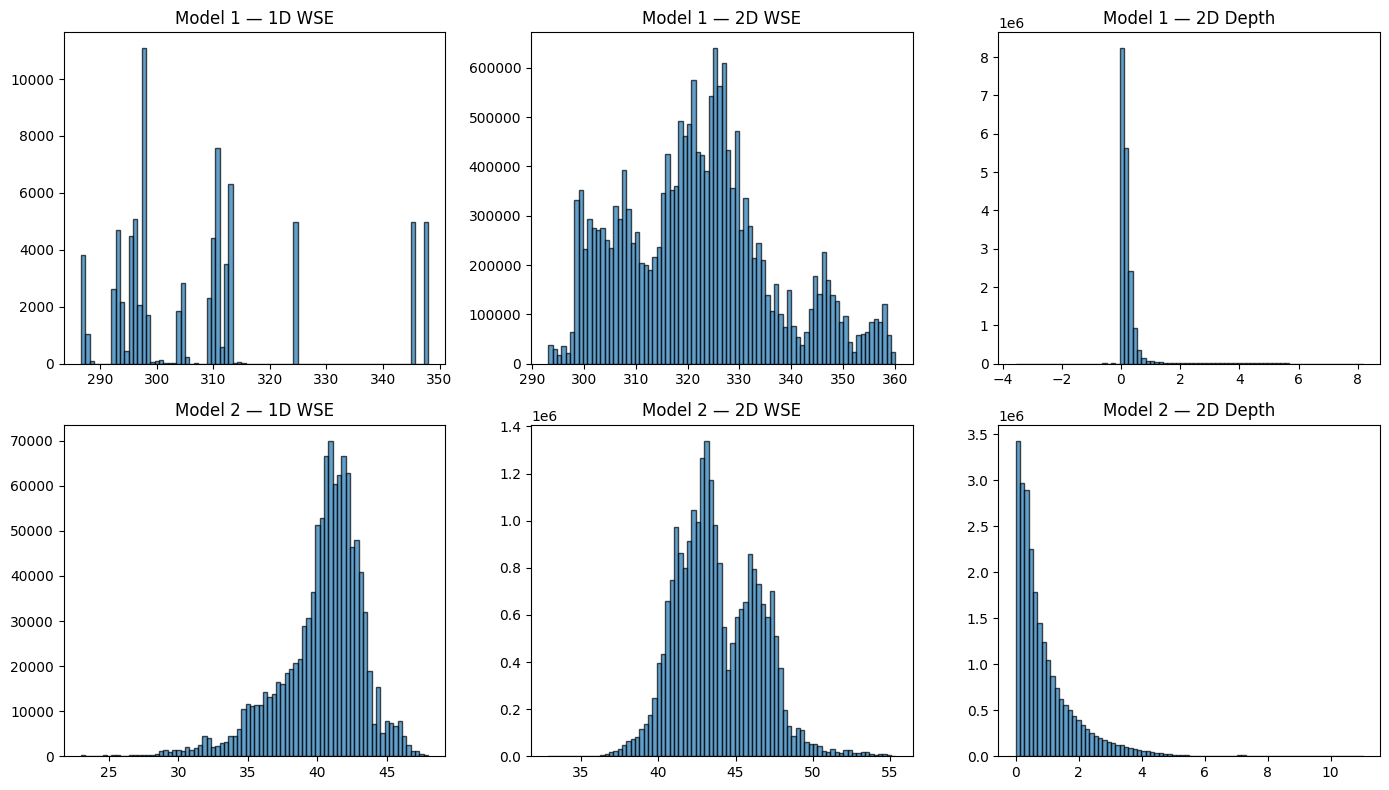

M1-1D depth: mean=0.0592 std=24.8350 min=-50.9608 max=54.9595 %neg=60.8%
M1-2D depth: mean=0.2572 std=0.6270 min=-3.5562 max=8.1642 %neg=1.4%
M2-1D depth: mean=4.7790 std=4.8382 min=-14.5947 max=20.9952 %neg=15.3%
M2-2D depth: mean=0.9289 std=1.0054 min=-0.0000 max=11.0138 %neg=0.8%


In [2]:
# Collect all Water_Level and Depth values across events for Model 1 & 2
def collect_targets(dataset, model_id, max_events=20):
    subset = dataset.filter_by_model(model_id)
    wl_1d, wl_2d, depth_1d, depth_2d = [], [], [], []
    for i in range(min(len(subset), max_events)):
        s = subset[i]
        s1d, s2d = s["static_1d_nodes"], s["static_2d_nodes"]
        d1d, d2d = s["dynamic_1d_nodes"], s["dynamic_2d_nodes"]
        min_2d = get_min_elevation_filled(s2d)
        inv_1d = s1d["invert_elevation"].values
        if not d1d.empty and "water_level" in d1d.columns:
            wl_1d.extend(d1d["water_level"].values)
            nidx = d1d["node_idx"].values.astype(int)
            depth_1d.extend((d1d["water_level"].values - inv_1d[nidx]).tolist())
        if not d2d.empty and "water_level" in d2d.columns:
            wl_2d.extend(d2d["water_level"].values)
            nidx = d2d["node_idx"].values.astype(int)
            depth_2d.extend((d2d["water_level"].values - min_2d[nidx]).tolist())
    return wl_1d, wl_2d, depth_1d, depth_2d

wl_1d_m1, wl_2d_m1, d_1d_m1, d_2d_m1 = collect_targets(ds, "1")
wl_1d_m2, wl_2d_m2, d_1d_m2, d_2d_m2 = collect_targets(ds, "2")

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes[0,0].hist(wl_1d_m1, bins=80, edgecolor="black", alpha=0.7); axes[0,0].set_title("Model 1 — 1D WSE")
axes[0,1].hist(wl_2d_m1, bins=80, edgecolor="black", alpha=0.7); axes[0,1].set_title("Model 1 — 2D WSE")
axes[0,2].hist(d_2d_m1, bins=80, edgecolor="black", alpha=0.7); axes[0,2].set_title("Model 1 — 2D Depth")
axes[1,0].hist(wl_1d_m2, bins=80, edgecolor="black", alpha=0.7); axes[1,0].set_title("Model 2 — 1D WSE")
axes[1,1].hist(wl_2d_m2, bins=80, edgecolor="black", alpha=0.7); axes[1,1].set_title("Model 2 — 2D WSE")
axes[1,2].hist(d_2d_m2, bins=80, edgecolor="black", alpha=0.7); axes[1,2].set_title("Model 2 — 2D Depth")
plt.tight_layout(); plt.savefig("eda_target_histograms.png", dpi=120); plt.show()

for name, arr in [("M1-1D depth", np.array(d_1d_m1)), ("M1-2D depth", np.array(d_2d_m1)), ("M2-1D depth", np.array(d_1d_m2)), ("M2-2D depth", np.array(d_2d_m2))]:
    arr = arr[np.isfinite(arr)]
    print(f"{name}: mean={arr.mean():.4f} std={arr.std():.4f} min={arr.min():.4f} max={arr.max():.4f} %neg={(arr<0).sum()/len(arr)*100:.1f}%")

## 2. Stationarity — Autocorrelation

Does depth at t strongly predict depth at t+1?

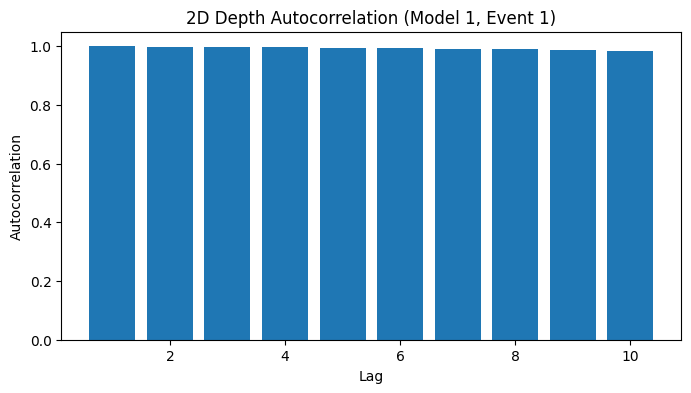

Lag-1 autocorrelation: 0.9996


In [3]:
# Autocorrelation: corr(depth_t, depth_{t+lag})
def compute_autocorr(depths_ts, max_lag=10):
    """depths_ts: [T, N]"""
    T, N = depths_ts.shape
    ac = []
    for lag in range(1, min(max_lag+1, T//2)):
        d_t = depths_ts[:-lag].ravel()
        d_tlag = depths_ts[lag:].ravel()
        m = np.isfinite(d_t) & np.isfinite(d_tlag)
        if m.sum() > 100:
            ac.append(np.corrcoef(d_t[m], d_tlag[m])[0,1])
        else:
            ac.append(np.nan)
    return ac

def get_depth_ts(sample):
    d2d = sample["dynamic_2d_nodes"]
    s2d = sample["static_2d_nodes"]
    min_e = get_min_elevation_filled(s2d)
    n_nodes = len(s2d)
    ts = sorted(d2d["timestep"].unique())
    arr = np.full((len(ts), n_nodes), np.nan)
    for i, t in enumerate(ts):
        m = d2d["timestep"] == t
        rows = d2d.loc[m].sort_values("node_idx")
        wl = rows["water_level"].values
        arr[i] = wl - min_e[rows["node_idx"].values.astype(int)]
    return arr

sample = ds.filter_by_model("1")[0]
depths = get_depth_ts(sample)
ac = compute_autocorr(depths)
plt.figure(figsize=(8,4))
plt.bar(range(1, len(ac)+1), ac); plt.xlabel("Lag"); plt.ylabel("Autocorrelation")
plt.title("2D Depth Autocorrelation (Model 1, Event 1)"); plt.savefig("eda_autocorr.png", dpi=120); plt.show()
print(f"Lag-1 autocorrelation: {ac[0]:.4f}")

## 3. Outlier Hunt — Model 1 Depth std=24.8

Isolate nodes with extreme depth variance. Are they physical or data errors?

In [4]:
# Per-node depth std across events (1D and 2D)
def node_depth_stds(dataset, model_id):
    subset = dataset.filter_by_model(model_id)
    s0 = subset[0]
    n_1d = len(s0["static_1d_nodes"])
    n_2d = len(s0["static_2d_nodes"])
    min_2d = get_min_elevation_filled(s0["static_2d_nodes"])
    inv_1d = s0["static_1d_nodes"]["invert_elevation"].values
    acc_1d = {i: [] for i in range(n_1d)}
    acc_2d = {i: [] for i in range(n_2d)}
    for i in range(len(subset)):
        s = subset[i]
        d1, d2 = s["dynamic_1d_nodes"], s["dynamic_2d_nodes"]
        if not d1.empty:
            for _, r in d1.iterrows():
                ni = int(r["node_idx"])
                acc_1d[ni].append(r["water_level"] - inv_1d[ni])
        if not d2.empty:
            me = get_min_elevation_filled(s["static_2d_nodes"])
            for _, r in d2.iterrows():
                ni = int(r["node_idx"])
                acc_2d[ni].append(r["water_level"] - me[ni])
    std_1d = np.array([np.std(acc_1d[i]) if acc_1d[i] else 0 for i in range(n_1d)])
    std_2d = np.array([np.std(acc_2d[i]) if acc_2d[i] else 0 for i in range(n_2d)])
    return std_1d, std_2d

std_1d_m1, std_2d_m1 = node_depth_stds(ds, "1")
print(f"Model 1 — 1D depth: mean_std={std_1d_m1.mean():.4f} max_std={std_1d_m1.max():.4f}")
print(f"Model 1 — 2D depth: mean_std={std_2d_m1.mean():.4f} max_std={std_2d_m1.max():.4f}")
print(f"1D nodes with std>10: {(std_1d_m1>10).sum()}")
print(f"2D nodes with std<0.01 (dry): {(std_2d_m1<0.01).sum()} ({(std_2d_m1<0.01).sum()/len(std_2d_m1)*100:.1f}%)")

Model 1 — 1D depth: mean_std=0.3749 max_std=0.8142
Model 1 — 2D depth: mean_std=0.1515 max_std=1.8995
1D nodes with std>10: 0
2D nodes with std<0.01 (dry): 0 (0.0%)


## 4. 1D-2D Correlation — Rainfall vs Pipe Surcharge Lag

How fast does the system react?

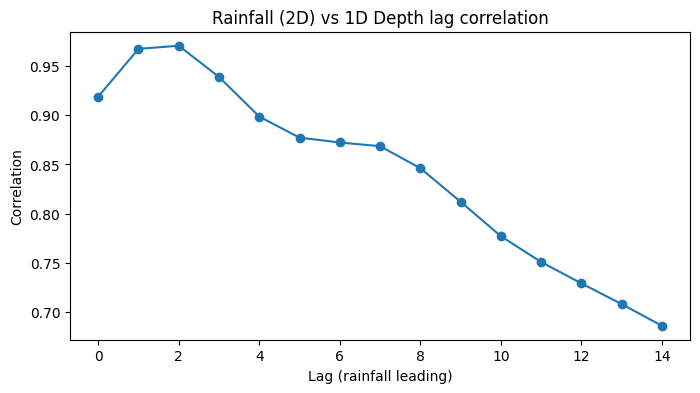

Best lag: 2 (corr=0.9706)


In [5]:
# Lag correlation: rainfall vs 1D depth (proxy for surcharge)
def lag_corr_rainfall_depth(sample, max_lag=15):
    d1d = sample["dynamic_1d_nodes"]
    d2d = sample["dynamic_2d_nodes"]
    if d1d.empty or d2d.empty: return []
    ts = sorted(d2d["timestep"].unique())
    rain_mean = d2d.groupby("timestep")["rainfall"].mean()
    depth_1d_mean = d1d.groupby("timestep")["water_level"].mean()
    rain = np.array([rain_mean.get(t, 0) for t in ts])
    dep = np.array([depth_1d_mean.get(t, np.nan) for t in ts])
    dep = np.nan_to_num(dep, nan=np.nanmean(dep))
    corrs = []
    for lag in range(max_lag):
        if lag == 0:
            corrs.append(np.corrcoef(rain, dep)[0,1])
        else:
            corrs.append(np.corrcoef(rain[:-lag], dep[lag:])[0,1])
    return corrs

sample = ds.filter_by_model("1")[0]
corrs = lag_corr_rainfall_depth(sample)
plt.figure(figsize=(8,4))
plt.plot(range(len(corrs)), corrs, 'o-')
plt.xlabel("Lag (rainfall leading)"); plt.ylabel("Correlation")
plt.title("Rainfall (2D) vs 1D Depth lag correlation"); plt.savefig("eda_lag_corr.png", dpi=120); plt.show()
best_lag = np.argmax(np.abs(corrs))
print(f"Best lag: {best_lag} (corr={corrs[best_lag]:.4f})")

## 5. Dry Node Imbalance

% of nodes with depth=0 (or near-zero). Justifies LeakyReLU.

In [6]:
# Dry nodes: depth ≈ 0 across all timesteps
def dry_node_pct(dataset, model_id, threshold=1e-4):
    std_1d, std_2d = node_depth_stds(dataset, model_id)
    dry_1d = (std_1d < threshold).sum() / len(std_1d) * 100
    dry_2d = (std_2d < threshold).sum() / len(std_2d) * 100
    return dry_1d, dry_2d

for mid in ds.get_model_ids():
    d1, d2 = dry_node_pct(ds, mid)
    print(f"Model {mid}: 1D dry (<0.0001 std) = {d1:.1f}% | 2D dry = {d2:.1f}%")

Model 1: 1D dry (<0.0001 std) = 23.5% | 2D dry = 0.0%
Model 2: 1D dry (<0.0001 std) = 1.0% | 2D dry = 0.0%


## 6. EDA Summary Report

In [7]:
print("="*60)
print("EDA DEEP DIVE — SUMMARY")
print("="*60)
print("1. Target: Check histograms — if heavy-tailed, consider log(1+ depth)")
print("2. Autocorr: High lag-1 → temporal model (GRU) important")
print("3. Outliers: 1D std=24.8 driven by constant nodes — per-node norm needed")
print("4. Lag: Rainfall→Depth delay informs feature window")
print("5. Dry nodes: High % → LeakyReLU (not ReLU)")
print("="*60)

EDA DEEP DIVE — SUMMARY
1. Target: Check histograms — if heavy-tailed, consider log(1+ depth)
2. Autocorr: High lag-1 → temporal model (GRU) important
3. Outliers: 1D std=24.8 driven by constant nodes — per-node norm needed
4. Lag: Rainfall→Depth delay informs feature window
5. Dry nodes: High % → LeakyReLU (not ReLU)
